# 06 — Gesture Morphology

## The question

Watching people use the app, some **fling** the content and let it coast; others **hold and
drag** it down under the finger. Both produce scroll events, and the pipeline counts them
identically. But they are different motor acts.

This notebook asks what *kind* of contact each touch is, rather than how fast or how often
it happened.

## The physical discriminator

A fling and a drag differ in one directly observable way: **momentum**.

```
  FLING                              DRAG
  ─────                              ────
  finger down                        finger down
  ├─ content moves                   ├─ content moves
  finger up  ← release               finger up  ← release
  │                                  │
  └─ content KEEPS MOVING            └─ content STOPS DEAD
     (scroll events continue)           (no further scroll events)
```

That is enough to classify every scroll gesture without guessing, and it validates itself:
if the classes are real, drags should show **zero** coast by construction, and — being
finger-driven work rather than a throw — should be held **longer** than flings. Section 4
checks both.

## What "morphology" means here

Not *when* a gesture happened (that is notebook 04) and not what the handset felt while it
happened (notebook 05), but the **shape of the contact itself**:

| aspect | question | why it might be personal |
|---|---|---|
| **class** | fling or drag or tap or swipe? | interaction style |
| **amplitude** | how far does one push move the content? | reach, confidence, screen mental model |
| **duration** | how long is the finger down? | deliberate vs glancing |
| **efficiency** | content distance per ms of contact | how hard the push is thrown |
| **path** | what shape does the finger trace? | steadiness — but see Section 11 |

## What this notebook does not do

No feature scoring, no ranking, no verdict. Where the original version computed a
separability number, this one plots the distribution that number was summarising.

## Sections

1. Setup
2. Extracting touch interactions
3. The taxonomy
4. Does the taxonomy hold up?
5. Gesture mix — the interaction style fingerprint
6. Scroll morphology — the shape of one push
7. Push and coast — the physics of a fling
8. Amplitude versus pace
9. Hold duration, split by gesture class
10. Drag and swipe gestures
11. Path shape, and a feature that does not work
12. Does any of this hold within a person?
13. Availability — who can be measured
14. Data-quality notes and rejected derivations
15. Per-participant cards
16. Open questions

## 1. Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

pd.set_option('display.max_columns', 60); pd.set_option('display.width', 210)
mpl.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.22,
                     'axes.titlesize': 11, 'axes.labelsize': 10, 'legend.fontsize': 9})

_CANDIDATES = ["../../data/processed/raw_events.parquet",
               "data/processed/raw_events.parquet",
               "raw_events.parquet",
               "/mnt/user-data/uploads/raw_events.parquet"]
_src = next((p for p in _CANDIDATES if Path(p).exists()), None)
if _src is None:
    raise FileNotFoundError(f"no raw events file found; tried {_CANDIDATES}")
raw_all = pd.read_parquet(_src)
raw_all['deviceFamily'] = raw_all['deviceFamily'].astype(str).str.lower()
raw_all['tRelMs'] = pd.to_numeric(raw_all['tRelMs'], errors='coerce')
raw_all = raw_all.loc[raw_all['tRelMs'].notna()].copy()
raw = raw_all.loc[raw_all['deviceFamily'] == 'mobile'].copy()

SCROLL_KINDS = ['scroll', 'window_scroll']

session_index = (raw.groupby(['participantId', 'sessionId'], dropna=False)
                 .agg(duration_s=('tRelMs', lambda s: s.max() / 1000.0),
                      started=('timestampIso', 'min')).reset_index())
session_index['session_start'] = pd.to_datetime(session_index['started'], utc=True, errors='coerce')
session_index = session_index.sort_values(['participantId', 'session_start']).reset_index(drop=True)
session_index['session_no'] = session_index.groupby('participantId').cumcount() + 1
SESSION_LABEL = {r.sessionId: f"{r.participantId} s{r.session_no}" for r in session_index.itertuples()}
SESSION_ORDER = session_index.sort_values(['participantId', 'session_no'])['sessionId'].tolist()

_p_dur = session_index.groupby('participantId')['duration_s'].median().sort_values(ascending=False)
PARTICIPANTS = _p_dur.index.astype(str).tolist()
_QUAL = plt.get_cmap('tab10')
PCOL = {p: _QUAL(i % 10) for i, p in enumerate(PARTICIPANTS)}
def pcolor(p): return PCOL.get(str(p), '0.5')

print(f"Loaded {_src}")
print(f"mobile: {raw['sessionId'].nunique()} sessions, {len(PARTICIPANTS)} participants")
for k in ['touchstart', 'touchend', 'touchmove'] + SCROLL_KINDS:
    print(f"  {k:16s} {(raw['kind'] == k).sum():,}")

Loaded /mnt/user-data/uploads/raw_events.parquet
mobile: 20 sessions, 9 participants
  touchstart       3,553
  touchend         3,553
  touchmove        61,285
  scroll           31,249
  window_scroll    15,723


## 2. Extracting touch interactions

One row per `touchstart` -> `touchend` pair, with the `touchmove` path and any scroll
activity attached.

Two quantities are recorded either side of release, and the distinction between them is the
entire basis of the classification:

- **`scroll_during`** — content movement while the finger is down.
- **`scroll_coast`** — content movement in the window *after* the finger lifts.

Everything else in this notebook follows from being able to measure those two separately.

In [2]:
COAST_WINDOW_MS = 2000.0     # how long after release to keep watching for coast


def build_interactions(raw_df):
    rows = []
    for sid, s in raw_df.groupby('sessionId'):
        s = s.sort_values('tRelMs')
        pid = s['participantId'].iloc[0]
        downs = s.loc[s['kind'] == 'touchstart', 'tRelMs'].to_numpy(float)
        ups = s.loc[s['kind'] == 'touchend', 'tRelMs'].to_numpy(float)
        mv = s.loc[s['kind'] == 'touchmove', ['tRelMs', 'payload_x', 'payload_y']]
        mv_t = mv['tRelMs'].to_numpy(float)
        mv_x = pd.to_numeric(mv['payload_x'], errors='coerce').to_numpy(float)
        mv_y = pd.to_numeric(mv['payload_y'], errors='coerce').to_numpy(float)
        sc = s.loc[s['kind'].isin(SCROLL_KINDS), ['tRelMs', 'payload_scrollTop']]
        sc_t = sc['tRelMs'].to_numpy(float)
        sc_v = pd.to_numeric(sc['payload_scrollTop'], errors='coerce').to_numpy(float)

        ui = 0
        for d in downs:
            while ui < len(ups) and ups[ui] < d:
                ui += 1
            if ui >= len(ups):
                break
            u = ups[ui]; ui += 1
            hold = u - d
            mm = (mv_t >= d) & (mv_t <= u)
            px, py, pt = mv_x[mm], mv_y[mm], mv_t[mm]
            n_moves = int(mm.sum())
            if n_moves >= 2:
                dx = np.diff(px); dy = np.diff(py)
                path_len = float(np.nansum(np.hypot(dx, dy)))
                disp = float(np.hypot(px[-1] - px[0], py[-1] - py[0]))
                start_x, start_y = float(px[0]), float(py[0])
                end_x, end_y = float(px[-1]), float(py[-1])
            else:
                path_len = disp = 0.0
                start_x = start_y = end_x = end_y = np.nan

            dm = (sc_t >= d) & (sc_t <= u)
            cm = (sc_t > u) & (sc_t <= u + COAST_WINDOW_MS)
            def span(vals):
                v = vals[np.isfinite(vals)]
                return float(np.nanmax(v) - np.nanmin(v)) if len(v) > 1 else 0.0
            scroll_during = span(sc_v[dm])
            scroll_coast = span(sc_v[cm])
            rows.append({'participantId': pid, 'sessionId': sid, 't_down': d, 'hold_ms': hold,
                         'n_moves': n_moves, 'path_len_px': path_len, 'displacement_px': disp,
                         'scroll_during_px': scroll_during, 'scroll_coast_px': scroll_coast,
                         'start_x': start_x, 'start_y': start_y, 'end_x': end_x, 'end_y': end_y})
    return pd.DataFrame(rows)


interactions = build_interactions(raw)
print(f"{len(interactions):,} touch interactions extracted "
      f"({interactions['sessionId'].nunique()} sessions)\n")
print(interactions[['hold_ms', 'n_moves', 'path_len_px', 'displacement_px',
                    'scroll_during_px', 'scroll_coast_px']].describe().round(1).to_string())

3,553 touch interactions extracted (20 sessions)

       hold_ms  n_moves  path_len_px  displacement_px  scroll_during_px  scroll_coast_px
count   3553.0   3553.0       3553.0           3553.0            3553.0           3553.0
mean     504.2     17.3        115.2             90.8              71.4            205.5
std     1047.1     33.4        150.0            103.5             133.4            316.3
min       11.0      0.0          0.0              0.0               0.0              0.0
25%       88.0      0.0          0.0              0.0               0.0              0.0
50%      174.0      6.0         69.6             51.5               0.0             76.0
75%      471.0     20.0        196.4            172.5             126.0            334.0
max    25699.0    678.0       2033.6            511.3            4315.0           4402.0


## 3. The taxonomy

Five classes, each defined by an observable rather than a guess:

| class | rule | what it physically is |
|---|---|---|
| `scroll_fling` | moved content, and it kept moving after release | thrown and left to coast |
| `scroll_drag` | moved content, stopped dead at release | pulled under the finger |
| `drag_swipe` | travelled a distance but moved no content | card swipe, pot drag |
| `long_press` | stayed put, stayed down | deliberate hold |
| `tap` | stayed put, released quickly | everything else |

The thresholds are constants so they can be moved. The one that matters is
`COAST_FRACTION_FLING` — Section 4 validates the split rather than trusting it.

In [3]:
COAST_FRACTION_FLING = 0.25   # coast must be >= this share of total scroll to count as a fling
MIN_SCROLL_PX = 5.0           # below this, no meaningful content movement
MIN_DRAG_PX = 20.0            # finger travel to count as a deliberate drag
LONG_PRESS_MS = 500.0


def classify(r):
    total_scroll = r['scroll_during_px'] + r['scroll_coast_px']
    if total_scroll >= MIN_SCROLL_PX:
        frac = r['scroll_coast_px'] / total_scroll if total_scroll > 0 else 0.0
        return 'scroll_fling' if frac >= COAST_FRACTION_FLING else 'scroll_drag'
    if r['displacement_px'] >= MIN_DRAG_PX:
        return 'drag_swipe'
    if r['hold_ms'] >= LONG_PRESS_MS:
        return 'long_press'
    return 'tap'


interactions['gesture'] = interactions.apply(classify, axis=1)
GESTURE_ORDER = ['scroll_fling', 'scroll_drag', 'drag_swipe', 'long_press', 'tap']
GCOL = dict(zip(GESTURE_ORDER, ['#c44e52', '#dd8452', '#4c72b0', '#8172b3', '#55a868']))

counts = interactions['gesture'].value_counts().reindex(GESTURE_ORDER).fillna(0).astype(int)
print("Gesture classes across the whole cohort:\n")
for g in GESTURE_ORDER:
    print(f"  {g:14s} {counts[g]:5,}  ({100*counts[g]/len(interactions):5.1f}%)")

Gesture classes across the whole cohort:

  scroll_fling   1,934  ( 54.4%)
  scroll_drag      375  ( 10.6%)
  drag_swipe       201  (  5.7%)
  long_press        26  (  0.7%)
  tap            1,017  ( 28.6%)


## 4. Does the taxonomy hold up?

A classification that cannot be checked is a guess with extra steps. Two predictions follow
directly from the physics, and both are falsifiable:

1. **Drags should show essentially zero coast** — that is the definition, so this mostly
   confirms the code does what it claims.
2. **Drags should be held longer than flings** — this one is *not* built into the rule. A
   drag is finger-driven work; a fling is a throw and release. If the classes were arbitrary
   there would be no reason for hold duration to differ.

Prediction 2 is the real test.

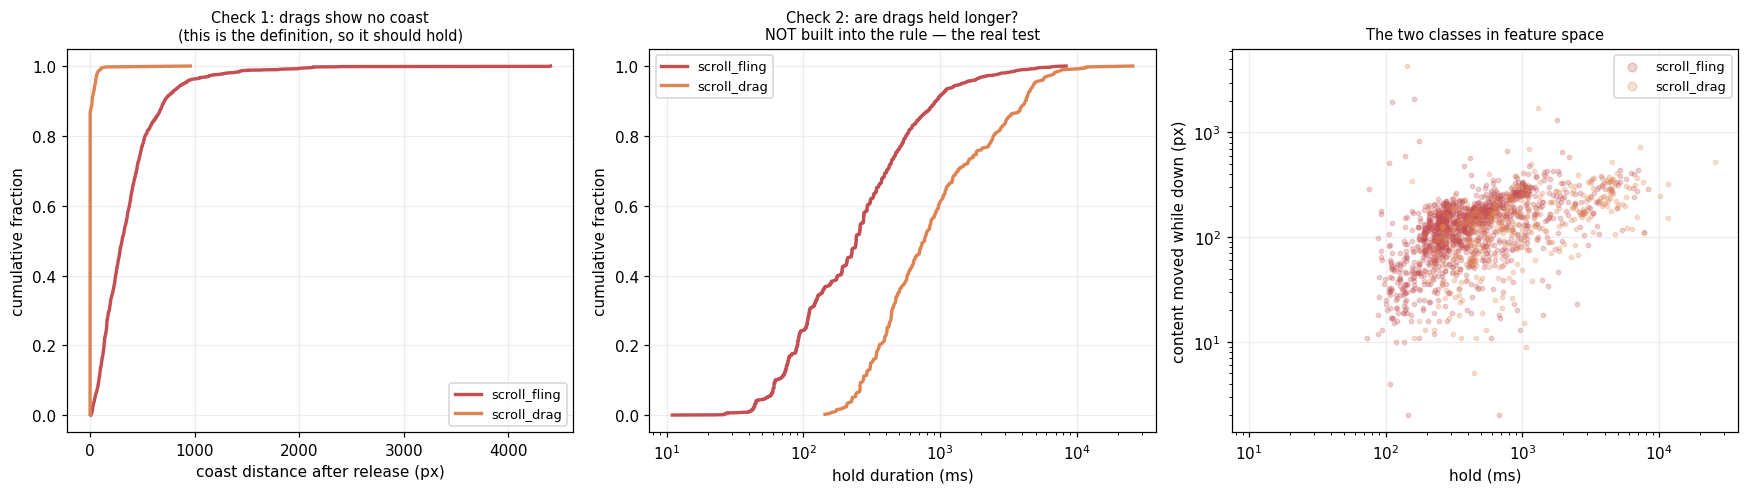

              hold_ms  scroll_during_px  scroll_coast_px
gesture                                                 
scroll_drag     771.0             134.0              0.0
scroll_fling    243.0              81.0            306.0

median hold -- fling 243 ms vs drag 771 ms  (drags held longer, as predicted)


In [4]:
def plot_taxonomy_validation(interactions):
    sc = interactions.loc[interactions['gesture'].isin(['scroll_fling', 'scroll_drag'])]
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

    ax = axes[0]
    for g in ['scroll_fling', 'scroll_drag']:
        v = sc.loc[sc['gesture'] == g, 'scroll_coast_px'].to_numpy()
        v = np.sort(v[np.isfinite(v)])
        ax.plot(v, np.arange(1, len(v) + 1) / len(v), color=GCOL[g], lw=2.2, label=g)
    ax.set_xlabel("coast distance after release (px)"); ax.set_ylabel("cumulative fraction")
    ax.set_title("Check 1: drags show no coast\n(this is the definition, so it should hold)",
                 fontsize=9.5)
    ax.legend(fontsize=8.5)

    ax = axes[1]
    for g in ['scroll_fling', 'scroll_drag']:
        v = sc.loc[sc['gesture'] == g, 'hold_ms'].to_numpy()
        v = np.sort(v[np.isfinite(v) & (v > 0)])
        ax.plot(v, np.arange(1, len(v) + 1) / len(v), color=GCOL[g], lw=2.2, label=g)
    ax.set_xscale('log'); ax.set_xlabel("hold duration (ms)"); ax.set_ylabel("cumulative fraction")
    ax.set_title("Check 2: are drags held longer?\nNOT built into the rule — the real test",
                 fontsize=9.5)
    ax.legend(fontsize=8.5)

    ax = axes[2]
    for g in ['scroll_fling', 'scroll_drag']:
        d = sc.loc[sc['gesture'] == g]
        ax.scatter(d['hold_ms'], d['scroll_during_px'], s=8, alpha=0.25, color=GCOL[g], label=g)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel("hold (ms)"); ax.set_ylabel("content moved while down (px)")
    ax.set_title("The two classes in feature space", fontsize=9.5)
    ax.legend(fontsize=8.5, markerscale=2)
    plt.tight_layout(); plt.show(); plt.close(fig)

    med = sc.groupby('gesture')[['hold_ms', 'scroll_during_px', 'scroll_coast_px']].median()
    print(med.round(1).to_string())
    print()
    f = med.loc['scroll_fling', 'hold_ms']; d = med.loc['scroll_drag', 'hold_ms']
    print(f"median hold -- fling {f:.0f} ms vs drag {d:.0f} ms  "
          f"({'drags held longer, as predicted' if d > f else 'PREDICTION FAILED: drags are not held longer'})")


plot_taxonomy_validation(interactions)

## 5. Gesture mix — the interaction style fingerprint

The share of each class per participant: the "what kind of user is this" summary, before
any timing feature is involved.

Read this as composition rather than magnitude. Two people can produce identical numbers of
scroll events while one flings everything and the other drags everything.

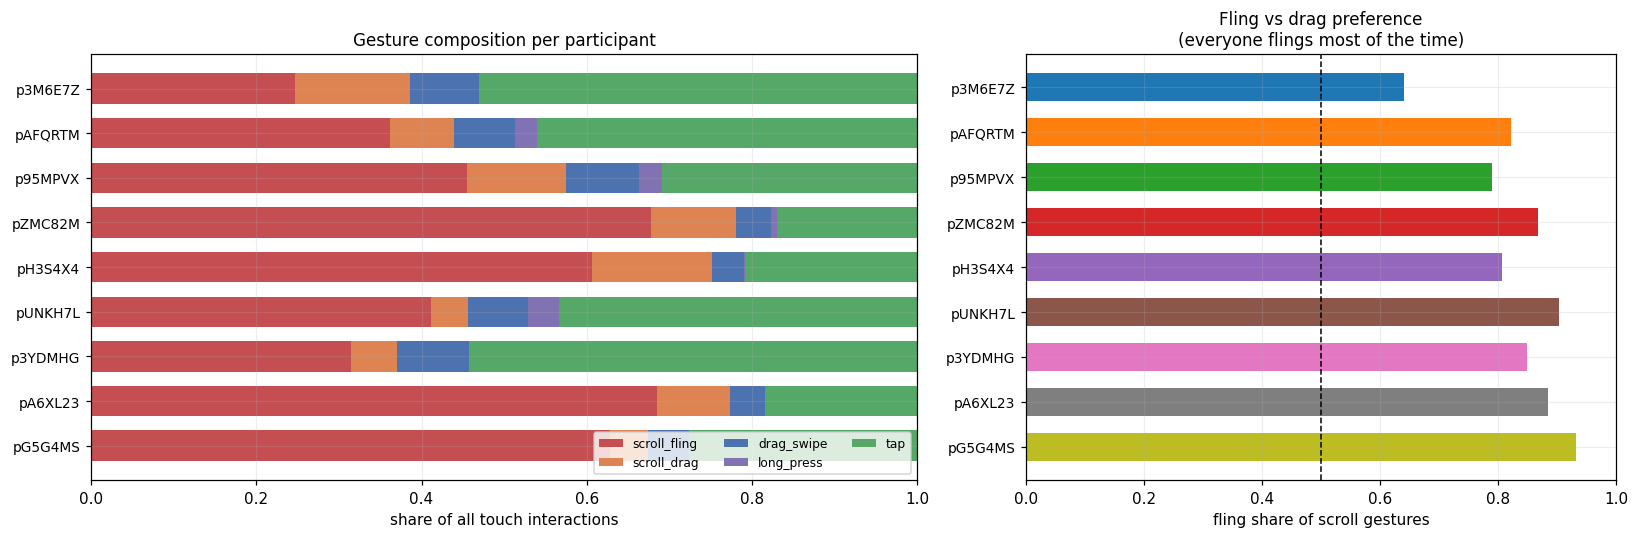

gesture        scroll_fling  scroll_drag  drag_swipe  long_press    tap
participantId                                                          
p3M6E7Z               0.247        0.139       0.082       0.000  0.531
pAFQRTM               0.361        0.079       0.073       0.026  0.461
p95MPVX               0.455        0.121       0.089       0.027  0.309
pZMC82M               0.677        0.103       0.043       0.007  0.170
pH3S4X4               0.606        0.145       0.040       0.001  0.208
pUNKH7L               0.412        0.044       0.074       0.037  0.434
p3YDMHG               0.315        0.056       0.086       0.000  0.543
pA6XL23               0.686        0.088       0.042       0.000  0.184
pG5G4MS               0.628        0.046       0.050       0.000  0.276


In [5]:
def plot_gesture_mix(interactions):
    mix = (interactions.groupby(['participantId', 'gesture']).size()
           .unstack(fill_value=0).reindex(columns=GESTURE_ORDER, fill_value=0))
    share = mix.div(mix.sum(axis=1), axis=0).reindex(PARTICIPANTS)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [1.4, 1]})
    ax = axes[0]
    left = np.zeros(len(share))
    y = np.arange(len(share))
    for g in GESTURE_ORDER:
        ax.barh(y, share[g], left=left, color=GCOL[g], height=0.68, label=g)
        left += share[g].to_numpy()
    ax.set_yticks(y); ax.set_yticklabels(share.index, fontsize=9); ax.invert_yaxis()
    ax.set_xlim(0, 1); ax.set_xlabel("share of all touch interactions")
    ax.set_title("Gesture composition per participant")
    ax.legend(fontsize=8, ncol=3, loc='lower right')

    ax = axes[1]
    sc = share[['scroll_fling', 'scroll_drag']]
    ratio = (sc['scroll_fling'] / sc.sum(axis=1)).dropna()
    yy = np.arange(len(ratio))
    ax.barh(yy, ratio.values, color=[pcolor(p) for p in ratio.index], height=0.62)
    ax.axvline(0.5, color='k', ls='--', lw=1)
    ax.set_yticks(yy); ax.set_yticklabels(ratio.index, fontsize=9); ax.invert_yaxis()
    ax.set_xlim(0, 1); ax.set_xlabel("fling share of scroll gestures")
    ax.set_title("Fling vs drag preference\n(everyone flings most of the time)")
    plt.tight_layout(); plt.show(); plt.close(fig)
    print(share.round(3).to_string())
    return share


mix_share = plot_gesture_mix(interactions)

## 6. Scroll morphology — the shape of one push

Within scroll gestures only, four aspects of the push, each physically distinct:

- **`scroll_during_px`** — how far the content moved while the finger was down. The closest
  thing to "how big a push does this person make".
- **`hold_ms`** — how long the finger stayed on the glass.
- **`scroll_coast_px`** — how far it ran on after release, set by the release velocity the OS
  computed internally.
- **`scroll_efficiency`** — total content distance per millisecond of contact: how hard the
  push was thrown relative to how long it took.

               scroll_during_px  hold_ms  scroll_coast_px  scroll_efficiency
participantId                                                               
p3M6E7Z                   109.0    660.0            102.0               0.40
pAFQRTM                    21.0    139.0            189.0               1.53
p95MPVX                    34.0    176.0            159.5               1.08
pZMC82M                    70.0    193.0            245.5               2.21
pH3S4X4                   134.0    507.0            230.0               0.75
pUNKH7L                   103.0    374.0            279.0               1.51
p3YDMHG                    34.5    176.5            194.5               0.95
pA6XL23                    96.0    261.0            344.0               1.92
pG5G4MS                   106.0    242.0            365.0               2.88


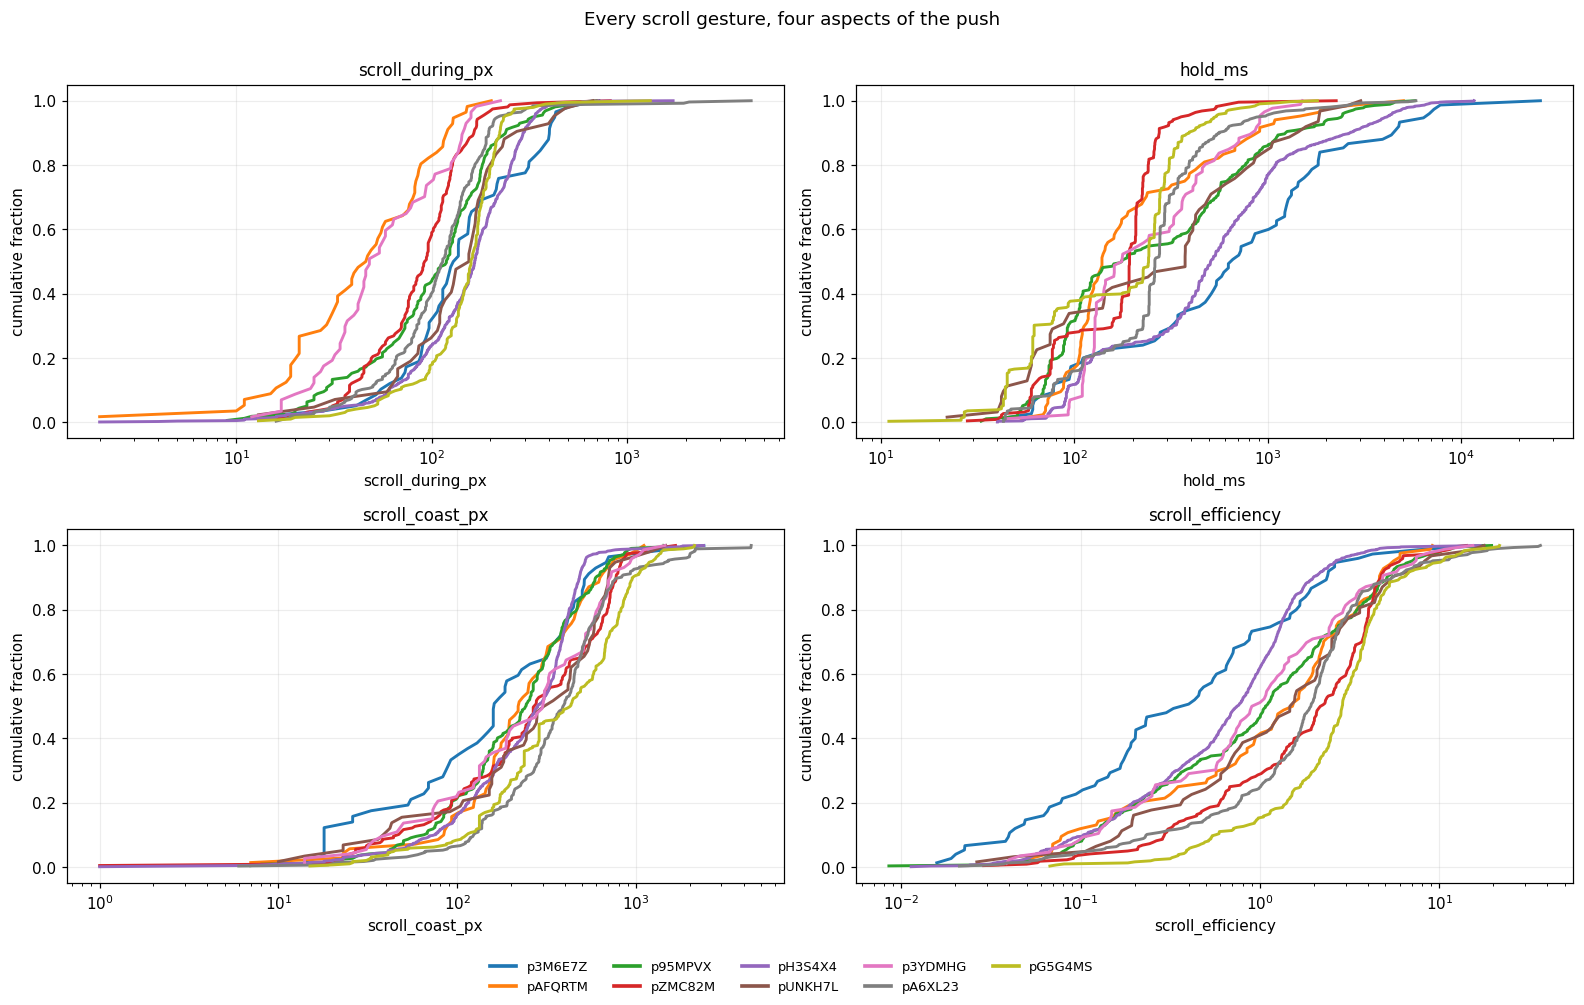

In [6]:
scroll_g = interactions.loc[interactions['gesture'].isin(['scroll_fling', 'scroll_drag'])].copy()
scroll_g['scroll_total_px'] = scroll_g['scroll_during_px'] + scroll_g['scroll_coast_px']
scroll_g['scroll_efficiency'] = scroll_g['scroll_total_px'] / scroll_g['hold_ms'].clip(lower=1)

MORPH = ['scroll_during_px', 'hold_ms', 'scroll_coast_px', 'scroll_efficiency']
print(scroll_g.groupby('participantId')[MORPH].median().reindex(PARTICIPANTS).round(2).to_string())


def plot_scroll_morphology(scroll_g):
    fig, axes = plt.subplots(2, 2, figsize=(14.5, 9))
    for ax, f in zip(axes.ravel(), MORPH):
        thin = []
        for p in PARTICIPANTS:
            v = scroll_g.loc[scroll_g['participantId'] == p, f].to_numpy()
            v = v[np.isfinite(v) & (v > 0)]
            if len(v) < 20:
                thin.append(p); continue
            v = np.sort(v)
            ax.plot(v, np.arange(1, len(v) + 1) / len(v), color=pcolor(p), lw=1.9)
        ax.set_xscale('log'); ax.set_xlabel(f); ax.set_ylabel("cumulative fraction")
        ax.set_title(f)
        if thin:
            ax.text(0.02, 0.97, "thin: " + ", ".join(thin), transform=ax.transAxes,
                    va='top', fontsize=7, color='#c44e52')
    handles = [Line2D([0], [0], color=pcolor(p), lw=2.4, label=p) for p in PARTICIPANTS]
    fig.legend(handles=handles, loc='lower center', ncol=5, frameon=False, fontsize=8.5)
    fig.suptitle("Every scroll gesture, four aspects of the push", y=1.0)
    plt.tight_layout(rect=[0, 0.05, 1, 1]); plt.show(); plt.close(fig)


plot_scroll_morphology(scroll_g)

## 7. Push and coast — the physics of a fling

A fling is a throw: the harder the content is pushed at release, the further it coasts. That
relationship should be visible directly, and it is a second independent check that the
classification is measuring something physical.

More interestingly, the *slope* of that relationship is itself behavioural. Someone who gets
a lot of coast from a small push is releasing with high velocity — a flick. Someone who
pushes far but coasts little is decelerating before release — a controlled placement.

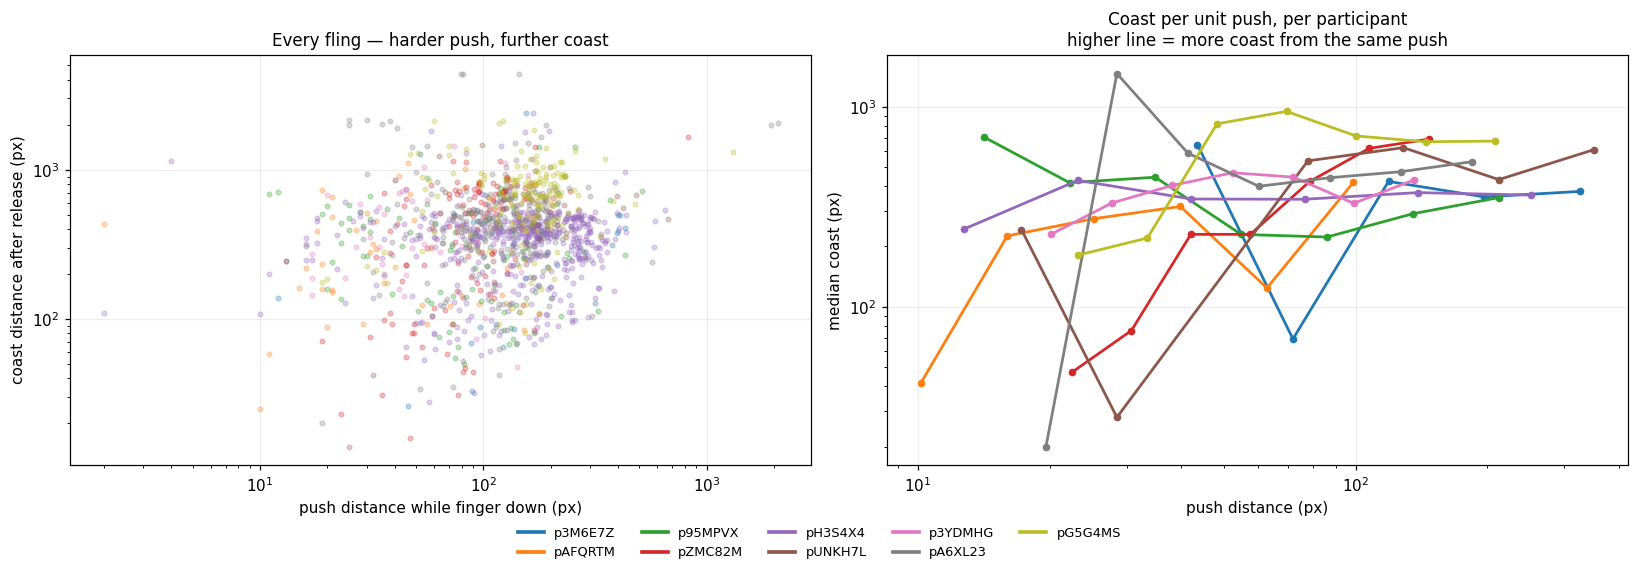

In [7]:
def plot_push_coast(scroll_g):
    fl = scroll_g.loc[scroll_g['gesture'] == 'scroll_fling']
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

    ax = axes[0]
    for p in PARTICIPANTS:
        d = fl.loc[fl['participantId'] == p]
        d = d.loc[(d['scroll_during_px'] > 0) & (d['scroll_coast_px'] > 0)]
        if len(d) < 15:
            continue
        ax.scatter(d['scroll_during_px'], d['scroll_coast_px'], s=9, alpha=0.28, color=pcolor(p))
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel("push distance while finger down (px)")
    ax.set_ylabel("coast distance after release (px)")
    ax.set_title("Every fling — harder push, further coast")

    ax = axes[1]
    for p in PARTICIPANTS:
        d = fl.loc[fl['participantId'] == p]
        d = d.loc[(d['scroll_during_px'] > 0) & (d['scroll_coast_px'] > 0)]
        if len(d) < 15:
            continue
        bins = np.logspace(np.log10(max(d['scroll_during_px'].min(), 5)),
                           np.log10(d['scroll_during_px'].quantile(0.95)), 8)
        d = d.assign(b=pd.cut(d['scroll_during_px'], bins))
        agg = d.groupby('b', observed=True)['scroll_coast_px'].median()
        ctr = [iv.mid for iv in agg.index]
        ax.plot(ctr, agg.values, 'o-', color=pcolor(p), lw=1.8, markersize=4)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel("push distance (px)"); ax.set_ylabel("median coast (px)")
    ax.set_title("Coast per unit push, per participant\nhigher line = more coast from the same push")
    handles = [Line2D([0], [0], color=pcolor(p), lw=2.4, label=p) for p in PARTICIPANTS]
    fig.legend(handles=handles, loc='lower center', ncol=5, frameon=False, fontsize=8.5)
    plt.tight_layout(rect=[0, 0.06, 1, 1]); plt.show(); plt.close(fig)


plot_push_coast(scroll_g)

## 8. Amplitude versus pace

Notebook 04 established that most of what separates these participants is pace wearing
different hats. So the question for every gesture feature is whether it is doing anything a
timing feature does not already do.

Each point is one participant: their median value against their median session duration. A
tight trend means the feature is largely re-measuring tempo. A scatter with no trend means
it is carrying something else.

**This replaces the original notebook's AUC-and-verdict section.** Same question — is this
feature independent of pace — shown as the relationship rather than reduced to a retained
separability score.

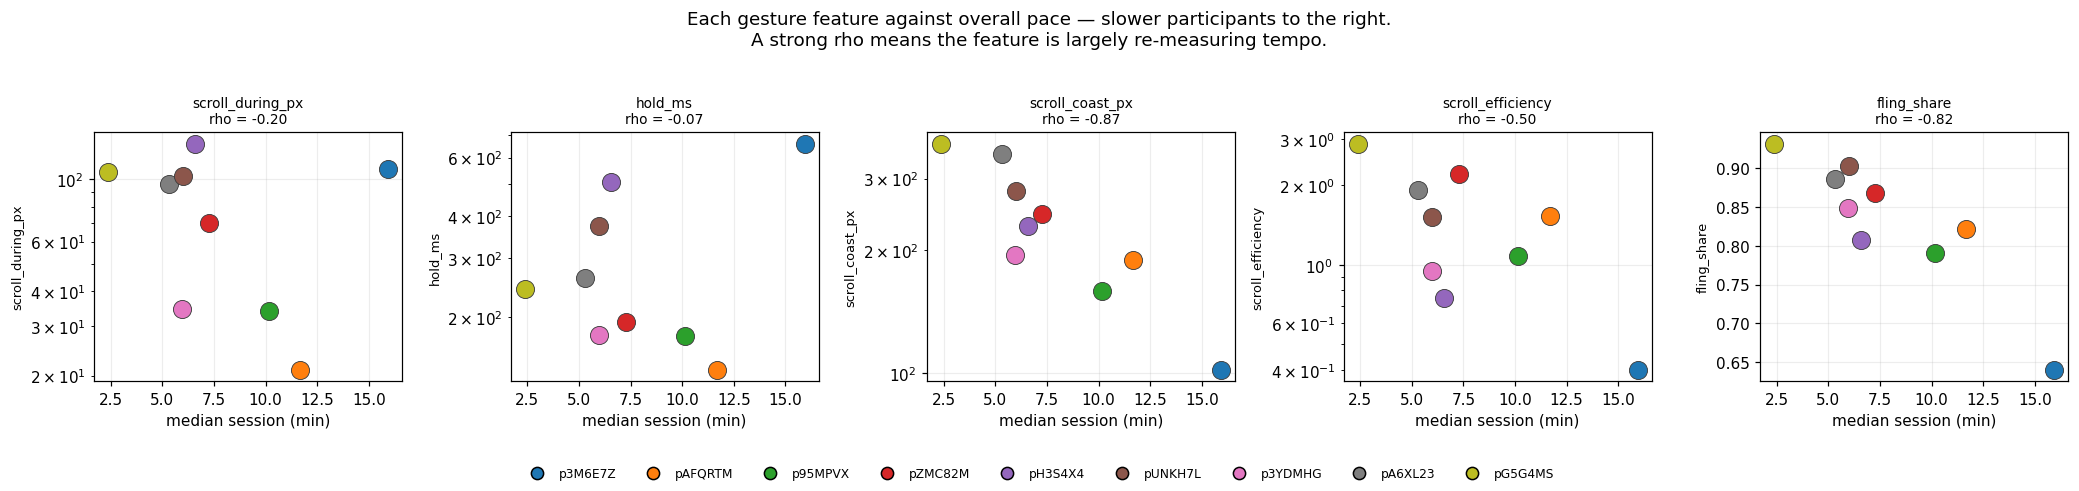

Spearman correlation with session duration (a proxy for overall pace):

  scroll_during_px       rho = -0.20
  hold_ms                rho = -0.07
  scroll_coast_px        rho = -0.87
  scroll_efficiency      rho = -0.50
  fling_share            rho = -0.82


In [8]:
def plot_pace_relationship(scroll_g, mix_share, session_index):
    dur = session_index.groupby('participantId')['duration_s'].median()
    med = scroll_g.groupby('participantId')[MORPH].median()
    med['fling_share'] = (mix_share['scroll_fling'] /
                          mix_share[['scroll_fling', 'scroll_drag']].sum(axis=1))
    d = med.join(dur.rename('duration_s')).dropna(subset=['duration_s'])

    cols = MORPH + ['fling_share']
    fig, axes = plt.subplots(1, len(cols), figsize=(19, 4.2))
    for ax, f in zip(axes, cols):
        dd = d.dropna(subset=[f])
        for p, r in dd.iterrows():
            ax.scatter(r['duration_s'] / 60, r[f], s=140, color=pcolor(p),
                       edgecolor='0.25', lw=0.6, zorder=3)
        rho = dd['duration_s'].corr(dd[f], method='spearman')
        ax.set_xlabel("median session (min)")
        ax.set_ylabel(f, fontsize=8.5)
        ax.set_title(f"{f}\nrho = {rho:+.2f}", fontsize=9)
        if f != 'fling_share':
            ax.set_yscale('log')
    handles = [Line2D([0], [0], marker='o', color='none', markerfacecolor=pcolor(p),
                      markersize=8, label=p) for p in PARTICIPANTS]
    fig.legend(handles=handles, loc='lower center', ncol=9, frameon=False, fontsize=8)
    fig.suptitle("Each gesture feature against overall pace — slower participants to the right.\n"
                 "A strong rho means the feature is largely re-measuring tempo.", y=1.03)
    plt.tight_layout(rect=[0, 0.09, 1, 1]); plt.show(); plt.close(fig)

    print("Spearman correlation with session duration (a proxy for overall pace):\n")
    for f in cols:
        dd = d.dropna(subset=[f])
        print(f"  {f:22s} rho = {dd['duration_s'].corr(dd[f], method='spearman'):+.2f}")


plot_pace_relationship(scroll_g, mix_share, session_index)

## 9. Hold duration, split by gesture class

Section 4 showed drags are held longer than flings *on average across everyone*. But hold
duration is also the most obvious candidate for a personal trait — some people rest the
finger, others are glancing.

The point of splitting by class is that pooling them is misleading. A participant who flings
a lot will show a short median hold purely because of their gesture mix, not because their
individual contacts are quick. **Class has to be conditioned on before the number means
anything.**

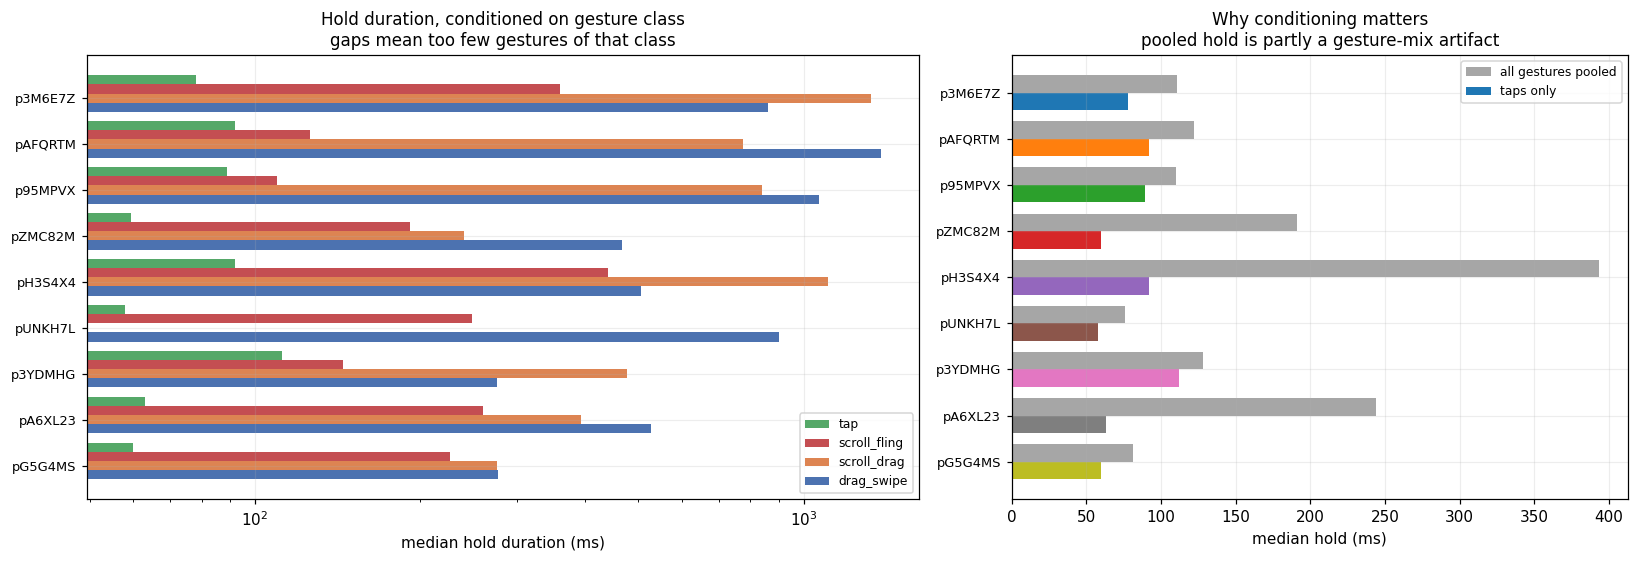

In [9]:
def plot_hold_by_class(interactions):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), gridspec_kw={'width_ratios': [1.35, 1]})

    ax = axes[0]
    classes = ['tap', 'scroll_fling', 'scroll_drag', 'drag_swipe']
    width = 0.8 / len(classes)
    y = np.arange(len(PARTICIPANTS))
    for k, g in enumerate(classes):
        vals = []
        for p in PARTICIPANTS:
            v = interactions.loc[(interactions['participantId'] == p) &
                                 (interactions['gesture'] == g), 'hold_ms']
            vals.append(v.median() if len(v) >= 8 else np.nan)
        ax.barh(y + (k - len(classes) / 2) * width, vals, height=width,
                color=GCOL[g], label=g)
    ax.set_yticks(y); ax.set_yticklabels(PARTICIPANTS, fontsize=8.5); ax.invert_yaxis()
    ax.set_xscale('log'); ax.set_xlabel("median hold duration (ms)")
    ax.set_title("Hold duration, conditioned on gesture class\n"
                 "gaps mean too few gestures of that class")
    ax.legend(fontsize=8)

    ax = axes[1]
    pooled = interactions.groupby('participantId')['hold_ms'].median().reindex(PARTICIPANTS)
    taps_only = (interactions.loc[interactions['gesture'] == 'tap']
                 .groupby('participantId')['hold_ms'].median().reindex(PARTICIPANTS))
    yy = np.arange(len(PARTICIPANTS)); w = 0.38
    ax.barh(yy - w / 2, pooled, height=w, color='0.65', label='all gestures pooled')
    ax.barh(yy + w / 2, taps_only, height=w,
            color=[pcolor(p) for p in PARTICIPANTS], label='taps only')
    ax.set_yticks(yy); ax.set_yticklabels(PARTICIPANTS, fontsize=8.5); ax.invert_yaxis()
    ax.set_xlabel("median hold (ms)")
    ax.set_title("Why conditioning matters\npooled hold is partly a gesture-mix artifact")
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_hold_by_class(interactions)

## 10. Drag and swipe gestures

`drag_swipe` covers contacts that travel a real distance but move no scrollable content:
card swipes, and the pot-drag interaction. These are rarer than scrolls but they are the
only gestures in the app with an explicit **target** — the app records whether a pot drag
was released in the right place.

That makes them the one place in this notebook where a gesture can be right or wrong, rather
than merely different — which is a different kind of behavioural signal from everything
else here.

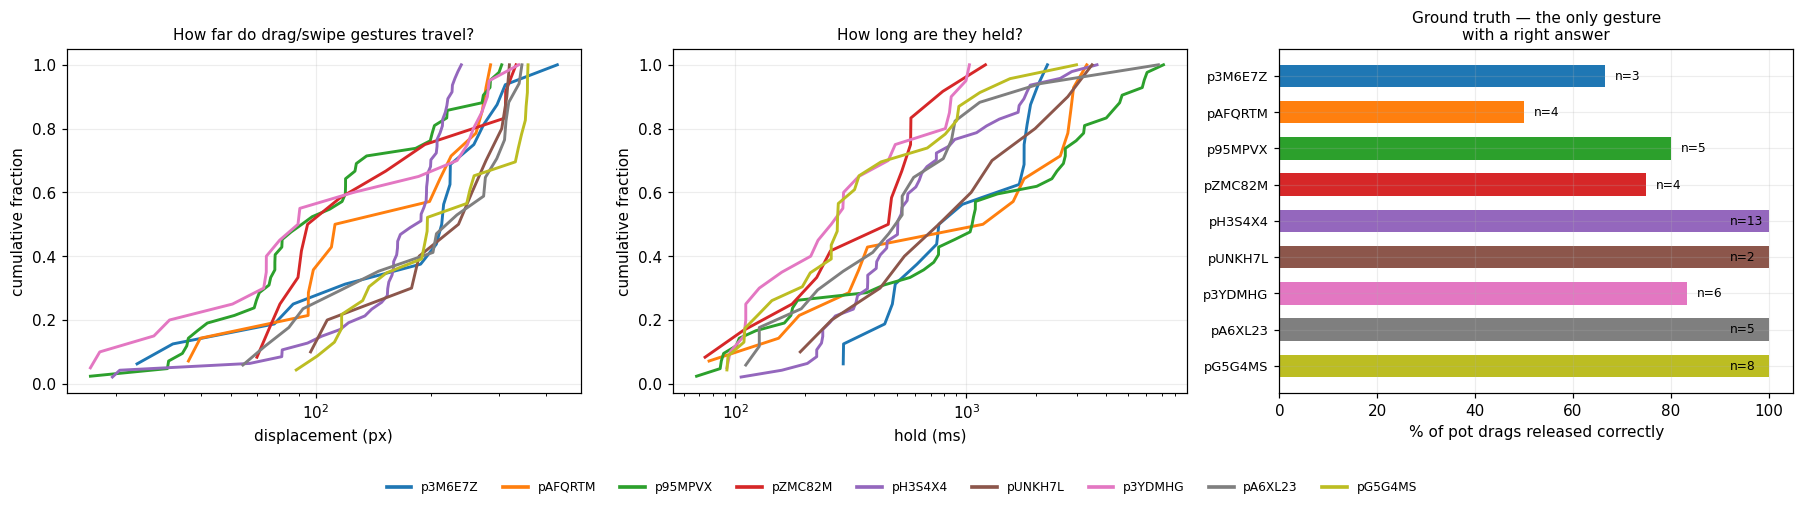

drag_swipe gestures: 201   pot_drag_release events: 50


In [10]:
def plot_drag_swipe(raw_df, interactions):
    ds = interactions.loc[interactions['gesture'] == 'drag_swipe']
    fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.6))

    ax = axes[0]
    for p in PARTICIPANTS:
        v = ds.loc[ds['participantId'] == p, 'displacement_px'].to_numpy()
        v = np.sort(v[np.isfinite(v) & (v > 0)])
        if len(v) < 8:
            continue
        ax.plot(v, np.arange(1, len(v) + 1) / len(v), color=pcolor(p), lw=1.9)
    ax.set_xscale('log'); ax.set_xlabel("displacement (px)"); ax.set_ylabel("cumulative fraction")
    ax.set_title("How far do drag/swipe gestures travel?", fontsize=10)

    ax = axes[1]
    for p in PARTICIPANTS:
        v = ds.loc[ds['participantId'] == p, 'hold_ms'].to_numpy()
        v = np.sort(v[np.isfinite(v) & (v > 0)])
        if len(v) < 8:
            continue
        ax.plot(v, np.arange(1, len(v) + 1) / len(v), color=pcolor(p), lw=1.9)
    ax.set_xscale('log'); ax.set_xlabel("hold (ms)"); ax.set_ylabel("cumulative fraction")
    ax.set_title("How long are they held?", fontsize=10)

    ax = axes[2]
    pot = raw_df.loc[raw_df['kind'] == 'pot_drag_release']
    if len(pot) and 'payload_correctRelease' in pot.columns:
        acc = (pot.groupby('participantId')['payload_correctRelease']
               .agg(['sum', 'size']).reindex(PARTICIPANTS).dropna())
        acc['pct'] = 100 * acc['sum'] / acc['size']
        yy = np.arange(len(acc))
        ax.barh(yy, acc['pct'], color=[pcolor(p) for p in acc.index], height=0.62)
        for i, (p, r) in enumerate(acc.iterrows()):
            ax.text(min(r['pct'] + 2, 92), i, f"n={int(r['size'])}", va='center', fontsize=8)
        ax.set_yticks(yy); ax.set_yticklabels(acc.index, fontsize=8.5); ax.invert_yaxis()
        ax.set_xlim(0, 105); ax.set_xlabel("% of pot drags released correctly")
        ax.set_title("Ground truth — the only gesture\nwith a right answer", fontsize=10)
    handles = [Line2D([0], [0], color=pcolor(p), lw=2.4, label=p) for p in PARTICIPANTS]
    fig.legend(handles=handles, loc='lower center', ncol=9, frameon=False, fontsize=8)
    plt.tight_layout(rect=[0, 0.08, 1, 1]); plt.show(); plt.close(fig)
    print(f"drag_swipe gestures: {len(ds)}   pot_drag_release events: "
          f"{(raw_df['kind'] == 'pot_drag_release').sum()}")


plot_drag_swipe(raw, interactions)

## 11. Path shape — and a correction to an earlier claim

Path **straightness** — displacement divided by path length — looks like an obvious
steadiness measure. A steady hand drags in a straight line; an unsteady one wanders, making
the path longer than the straight-line distance, so the ratio should sit below 1 and never
above it.

**An earlier version of this notebook reported that straightness exceeded 1.0 for 89% of
gestures** — geometrically impossible, and attributed to `touchmove` coalescing shortening
the reconstructed path. Recomputed here from `payload_x`/`payload_y` across every
multi-sample gesture in the export, that does not reproduce: the median is **0.990** and
only **0.05%** exceed 1.0, which is consistent with ordinary floating-point noise at the
boundary rather than a systematic artifact.

So the strong version of the claim is wrong for this data. What remains true, and still
matters:

- **The path is still undersampled.** Coalescing is real; the browser genuinely does not
  report every intermediate position. It just is not severe enough here to push the ratio
  past 1.
- **Undersampling still biases the measure**, and the middle panel below shows the direction:
  straightness drifts with how many samples the gesture happened to get. A feature whose
  value depends on sampling density is measuring the sampling as well as the hand.
- **The concern about speed still stands.** Faster gestures get proportionally fewer samples,
  so any residual bias works against slow careful movements — backwards for a steadiness
  measure.

The honest status is *biased and hard to interpret*, not *impossible*. It is kept here with
the correction attached rather than silently fixed, because the original claim has been cited
elsewhere in this project.

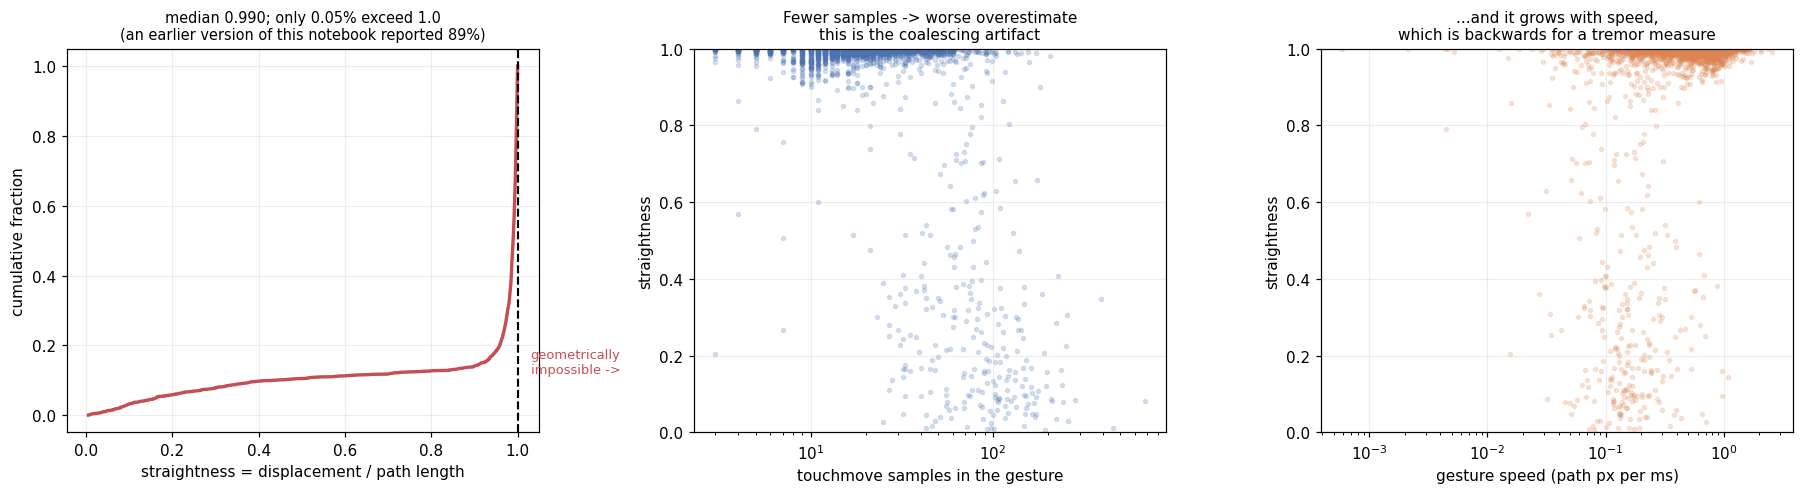

1,952 multi-sample gestures
  median straightness      : 0.990
  fraction exceeding 1.0   : 0.05%

This does NOT reproduce the earlier claim that 89% exceed 1.0. The measure is not
geometrically broken in this export -- but it is still sampling-dependent (middle
panel), so it measures touchmove density as well as hand steadiness.


In [11]:
def plot_path_failure(interactions):
    d = interactions.loc[(interactions['path_len_px'] > 0) &
                         (interactions['displacement_px'] > 0) &
                         (interactions['n_moves'] >= 3)].copy()
    d['straightness'] = d['displacement_px'] / d['path_len_px']

    fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.6))
    ax = axes[0]
    v = np.sort(d['straightness'].to_numpy())
    ax.plot(v, np.arange(1, len(v) + 1) / len(v), color='#c44e52', lw=2.2)
    ax.axvline(1.0, color='k', ls='--', lw=1.4)
    ax.text(1.03, 0.12, "geometrically\nimpossible ->", fontsize=8.5, color='#c44e52')
    ax.set_xlabel("straightness = displacement / path length")
    ax.set_ylabel("cumulative fraction")
    frac = float((d['straightness'] > 1.0).mean())
    ax.set_title(f"median {d['straightness'].median():.3f}; only {frac:.2%} exceed 1.0\n"
                 f"(an earlier version of this notebook reported 89%)", fontsize=9.5)

    ax = axes[1]
    ax.scatter(d['n_moves'], d['straightness'], s=7, alpha=0.2, color='#4c72b0')
    ax.axhline(1.0, color='k', ls='--', lw=1.2)
    ax.set_xscale('log')
    ax.set_xlabel("touchmove samples in the gesture")
    ax.set_ylabel("straightness")
    ax.set_ylim(0, min(3, d['straightness'].quantile(0.99)))
    ax.set_title("Fewer samples -> worse overestimate\nthis is the coalescing artifact", fontsize=10)

    ax = axes[2]
    d2 = d.loc[d['hold_ms'] > 0].copy()
    d2['px_per_ms'] = d2['path_len_px'] / d2['hold_ms']
    ax.scatter(d2['px_per_ms'], d2['straightness'], s=7, alpha=0.2, color='#dd8452')
    ax.axhline(1.0, color='k', ls='--', lw=1.2)
    ax.set_xscale('log')
    ax.set_xlabel("gesture speed (path px per ms)")
    ax.set_ylabel("straightness")
    ax.set_ylim(0, min(3, d['straightness'].quantile(0.99)))
    ax.set_title("...and it grows with speed,\nwhich is backwards for a tremor measure", fontsize=10)
    plt.tight_layout(); plt.show(); plt.close(fig)
    print(f"{len(d):,} multi-sample gestures")
    print(f"  median straightness      : {d['straightness'].median():.3f}")
    print(f"  fraction exceeding 1.0   : {frac:.2%}")
    print()
    print("This does NOT reproduce the earlier claim that 89% exceed 1.0. The measure is not")
    print("geometrically broken in this export -- but it is still sampling-dependent (middle")
    print("panel), so it measures touchmove density as well as hand steadiness.")


plot_path_failure(interactions)

## 12. Does any of this hold within a person?

Everything above pools all of a participant's sessions. The question that actually matters
for a model is whether these gesture properties are stable for one person across their own
repeat visits, or whether they drift session to session.

This is shown, not scored. Each participant's own session-level medians are plotted as
points, joined by a line. **Tight vertical clusters mean a stable trait; wide spreads mean
the pooled median above was hiding real session-to-session variation.**

Only participants with more than one session can appear.

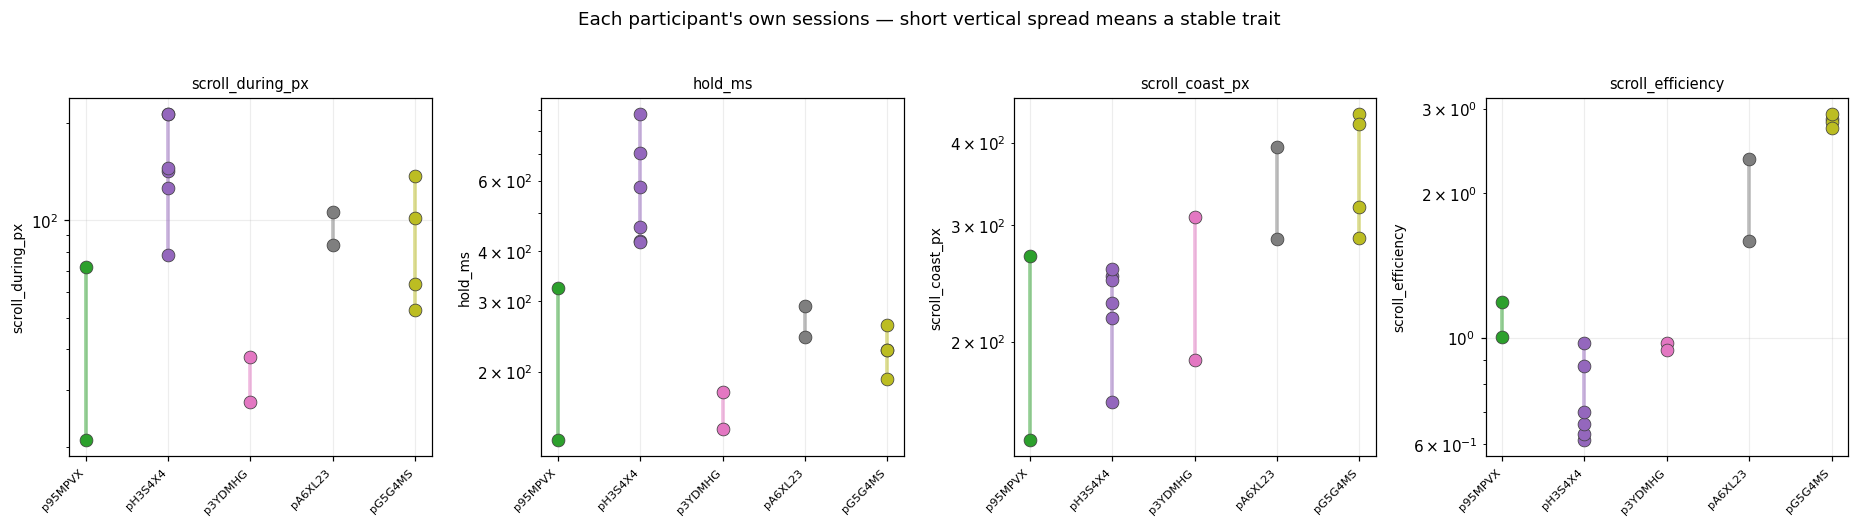

participants with >1 session: p95MPVX, pH3S4X4, p3YDMHG, pA6XL23, pG5G4MS


In [12]:
def plot_within_person(scroll_g, mix_share):
    multi = [p for p in PARTICIPANTS if (session_index['participantId'] == p).sum() > 1]
    feats = ['scroll_during_px', 'hold_ms', 'scroll_coast_px', 'scroll_efficiency']
    fig, axes = plt.subplots(1, len(feats), figsize=(17, 4.6))
    for ax, f in zip(axes, feats):
        per_sess = scroll_g.groupby(['participantId', 'sessionId'])[f].median().reset_index()
        for i, p in enumerate(multi):
            v = per_sess.loc[per_sess['participantId'] == p, f].dropna().to_numpy()
            if len(v) == 0:
                continue
            ax.scatter(np.full(len(v), i), v, s=70, color=pcolor(p), edgecolor='0.25',
                       lw=0.5, zorder=3)
            if len(v) > 1:
                ax.plot([i, i], [v.min(), v.max()], color=pcolor(p), lw=2.4, alpha=0.5, zorder=2)
        ax.set_xticks(range(len(multi)))
        ax.set_xticklabels(multi, rotation=45, ha='right', fontsize=7.5)
        ax.set_yscale('log'); ax.set_ylabel(f, fontsize=9)
        ax.set_title(f, fontsize=9.5)
    fig.suptitle("Each participant's own sessions — short vertical spread means a stable trait",
                 y=1.03)
    plt.tight_layout(); plt.show(); plt.close(fig)
    print(f"participants with >1 session: {', '.join(multi)}")


plot_within_person(scroll_g, mix_share)

## 13. Availability — who can be measured

gesture        scroll_fling  scroll_drag  drag_swipe  long_press  tap  total  sessions
participantId                                                                         
p3M6E7Z                  48           27          16           0  103    194         1
pAFQRTM                  69           15          14           5   88    191         1
p95MPVX                 215           57          42          13  146    473         2
pZMC82M                 191           29          12           2   48    282         1
pH3S4X4                 716          171          47           1  246   1181         6
pUNKH7L                  56            6          10           5   59    136         1
p3YDMHG                  73           13          20           0  126    232         2
pA6XL23                 279           36          17           0   75    407         2
pG5G4MS                 287           21          23           0  126    457         4


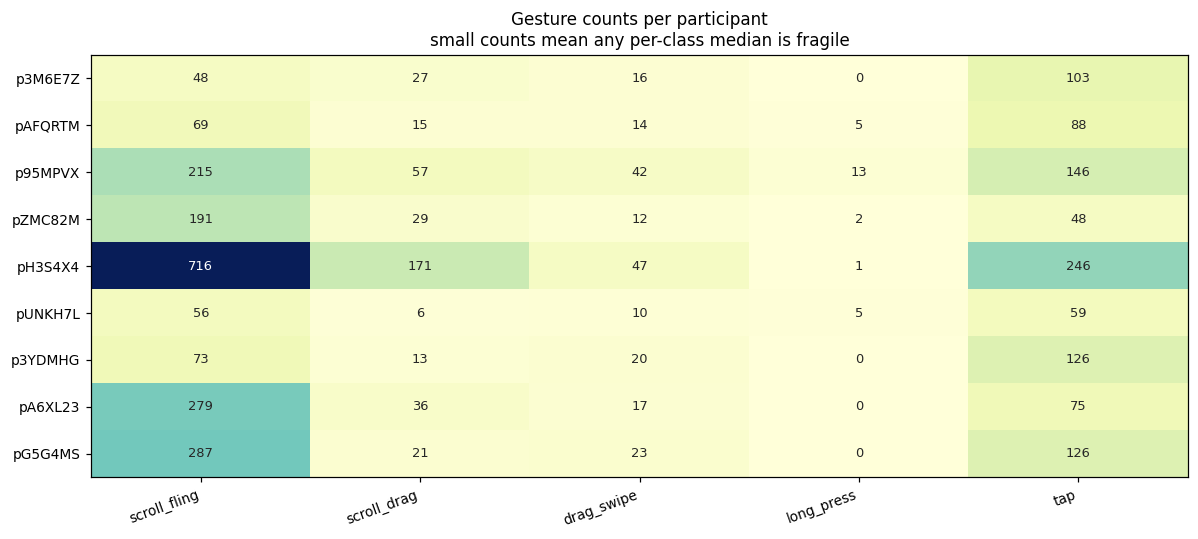

In [13]:
avail = (interactions.groupby('participantId')['gesture'].value_counts()
         .unstack(fill_value=0).reindex(columns=GESTURE_ORDER, fill_value=0)
         .reindex(PARTICIPANTS))
avail['total'] = avail.sum(axis=1)
avail['sessions'] = session_index.groupby('participantId').size().reindex(PARTICIPANTS)
print(avail.to_string())


def plot_availability(avail):
    fig, ax = plt.subplots(figsize=(11, 5))
    data = avail[GESTURE_ORDER].to_numpy(float)
    im = ax.imshow(data, cmap='YlGnBu', aspect='auto')
    ax.set_xticks(range(len(GESTURE_ORDER)))
    ax.set_xticklabels(GESTURE_ORDER, rotation=20, ha='right', fontsize=9)
    ax.set_yticks(range(len(avail))); ax.set_yticklabels(avail.index, fontsize=9)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            v = int(data[i, j])
            ax.text(j, i, str(v), ha='center', va='center', fontsize=8.5,
                    color='white' if v > data.max() * 0.55 else '0.15')
    ax.set_title("Gesture counts per participant\nsmall counts mean any per-class median is fragile")
    ax.grid(False)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_availability(avail)

## 14. Data-quality notes and rejected derivations

- **Path straightness is biased, not broken** (Section 11). An earlier version of this
  notebook reported 89% of gestures exceeding the geometric maximum of 1.0; recomputed here
  the median is 0.990 and only 0.05% exceed it. `touchmove` coalescing is real and does bias
  the measure with sampling density, but not severely enough to make it impossible. The
  earlier claim should be corrected wherever it has been carried forward.
- **`carousel_scroll` carries no scroll position.** Horizontal scrolling is therefore
  invisible to this notebook — thousands of events with nothing measurable. All scroll
  analysis here is vertical only.
- **`long_press` is very rare** across the cohort. Any per-participant statistic on it rests
  on a handful of gestures and should not be read as a trait.
- **Gesture class is a conditioning variable, not just a feature** (Section 9). A tap and a
  fling should not be pooled into one "touch duration" statistic — the pooled number is
  partly a gesture-mix artifact.
- **`COAST_FRACTION_FLING` is a threshold, and thresholds are choices.** Section 4 validates
  the resulting split against a prediction the rule does not encode, which is the best
  available check, but the boundary itself remains a judgement.
- **Coast distance is an OS computation, not a direct measurement.** The deceleration curve
  is iOS's, so coast reflects release velocity as the OS estimated it — a device-mediated
  quantity, which matters given every participant is on their own handset.

## 15. Per-participant cards

In [14]:
card = pd.DataFrame(index=PARTICIPANTS)
card['sessions'] = session_index.groupby('participantId').size().reindex(PARTICIPANTS)
card['gestures'] = avail['total']
card['fling_share'] = (mix_share['scroll_fling'] /
                       mix_share[['scroll_fling', 'scroll_drag']].sum(axis=1)).round(2)
for f in MORPH:
    card[f] = scroll_g.groupby('participantId')[f].median().reindex(PARTICIPANTS).round(1)
card['tap_hold_ms'] = (interactions.loc[interactions['gesture'] == 'tap']
                       .groupby('participantId')['hold_ms'].median().reindex(PARTICIPANTS).round(0))
print("Blank cells mean the quantity could not be computed for that person.\n")
print(card.to_string())

Blank cells mean the quantity could not be computed for that person.

         sessions  gestures  fling_share  scroll_during_px  hold_ms  scroll_coast_px  scroll_efficiency  tap_hold_ms
p3M6E7Z         1       194         0.64             109.0    660.0            102.0                0.4         78.0
pAFQRTM         1       191         0.82              21.0    139.0            189.0                1.5         92.0
p95MPVX         2       473         0.79              34.0    176.0            159.5                1.1         89.0
pZMC82M         1       282         0.87              70.0    193.0            245.5                2.2         60.0
pH3S4X4         6      1181         0.81             134.0    507.0            230.0                0.7         92.0
pUNKH7L         1       136         0.90             103.0    374.0            279.0                1.5         58.0
p3YDMHG         2       232         0.85              34.5    176.5            194.5                1.0        

## 16. Open questions

- **Section 12 is the check that matters and it has not been interpreted here.** Whether
  gesture amplitude is stable within a person across their own sessions is the difference
  between a trait and a description, and the plot is provided without a verdict precisely
  because five participants with repeat sessions is thin evidence either way.
- **Coast distance is device-mediated.** It reflects the OS's own deceleration model applied
  to a release velocity it computed internally. With every participant on a different
  handset, coast-based features carry an unresolved device confound — the same problem as
  notebook 05's amplitude features.
- **`drag_swipe` gestures have ground truth and it is barely used.** `pot_drag_release`
  records whether the drag ended in the right place. Accuracy, and how it relates to gesture
  speed or hold, is a directly answerable question this notebook only gestures at.
- **Gesture class has not been conditioned on task type.** The task sequence is identical
  across sessions, so whether a person flings more in some task types than others — and
  whether *that* pattern is personal — is testable and untested.
- **Nothing here examines gesture direction.** Every scroll is treated as a magnitude;
  whether someone consistently scrolls in longer downward than upward pushes, or starts
  gestures from a consistent screen region, is untouched and the coordinates are available.